In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load data
df = pd.read_excel("student_performance_data.xlsx")
df.head()

,Course,Strand,HS_GWA,Admission_Score,First_Year_GWA
0,BSCrim,ABM,99.0,83.6,96.0
1,BSCrim,STEM,91.6,81.5,82.7
2,BSCrim,GAS,75.0,78.0,70.0
3,BSN,TVL,77.1,66.6,76.5
4,BSCrim,HUMMS,92.1,87.8,93.2


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Course           500 non-null    object 
 1   Strand           500 non-null    object 
 2   HS_GWA           500 non-null    float64
 3   Admission_Score  500 non-null    float64
 4   First_Year_GWA   500 non-null    float64
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [4]:
# Course Distribution
df["Course"].value_counts(), df["Course"].value_counts(normalize=True) * 100

(Course
 BSCrim    122
 BSN       120
 BSED      106
 BEED       78
 BSA        74
 Name: count, dtype: int64,
 Course
 BSCrim    24.4
 BSN       24.0
 BSED      21.2
 BEED      15.6
 BSA       14.8
 Name: proportion, dtype: float64)

In [5]:
# Strand Distribution
df["Strand"].value_counts(), df["Strand"].value_counts(normalize=True) * 100

(Strand
 GAS        123
 ABM        115
 STEM        90
 HUMMS       88
 TVL         59
 Unknown     25
 Name: count, dtype: int64,
 Strand
 GAS        24.6
 ABM        23.0
 STEM       18.0
 HUMMS      17.6
 TVL        11.8
 Unknown     5.0
 Name: proportion, dtype: float64)

In [6]:
# Numerical Summary
df[["HS_GWA", "Admission_Score", "First_Year_GWA"]].describe()

,HS_GWA,Admission_Score,First_Year_GWA
count,500.000000,500.000000,500.000000
mean,85.149400,78.544400,86.657127
std,6.210197,7.363303,7.230918
min,75.000000,45.000000,70.000000
25%,80.675000,73.400000,81.700000
50%,84.900000,78.200000,87.650000
75%,89.800000,83.125000,92.525000
max,99.000000,95.000000,98.000000


In [7]:
# Correlation Matrix
corr_matrix = df[["HS_GWA", "Admission_Score", "First_Year_GWA"]].corr()
corr_matrix

,HS_GWA,Admission_Score,First_Year_GWA
HS_GWA,1.000000,0.578944,0.626097
Admission_Score,0.578944,1.000000,0.497431
First_Year_GWA,0.626097,0.497431,1.000000


In [8]:
# Course vs Performance
df.groupby("Course")["First_Year_GWA"].mean()

Course
BEED      87.982145
BSA       89.940541
BSCrim    82.924424
BSED      88.166981
BSN       86.232303
Name: First_Year_GWA, dtype: float64

In [9]:
# Strand vs Performance
df.groupby("Strand")["First_Year_GWA"].mean()

Strand
ABM        87.959547
GAS        83.978341
HUMMS      88.114539
STEM       91.026667
TVL        80.669492
Unknown    87.116000
Name: First_Year_GWA, dtype: float64

In [10]:
# Trend Analysis
df["HS_GWA_Group"] = pd.cut(df["HS_GWA"], bins=5)
df.groupby("HS_GWA_Group")["First_Year_GWA"].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27100\2274298895.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("HS_GWA_Group")["First_Year_GWA"].mean()


HS_GWA_Group
(74.976, 79.8]    80.113085
(79.8, 84.6]      84.778122
(84.6, 89.4]      88.053676
(89.4, 94.2]      91.289011
(94.2, 99.0]      93.990849
Name: First_Year_GWA, dtype: float64

In [11]:
df["Admission_Group"] = pd.cut(df["Admission_Score"], bins=5)
df.groupby("Admission_Group")["First_Year_GWA"].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_27100\1289506142.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Admission_Group")["First_Year_GWA"].mean()


Admission_Group
(44.95, 55.0]    74.750000
(55.0, 65.0]     79.184115
(65.0, 75.0]     82.832182
(75.0, 85.0]     87.580165
(85.0, 95.0]     91.312245
Name: First_Year_GWA, dtype: float64

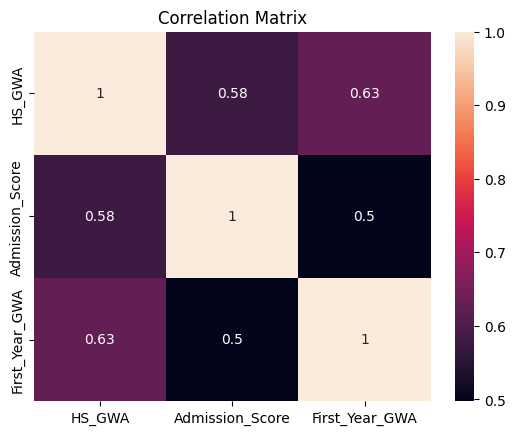

In [12]:
# Heatmap
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

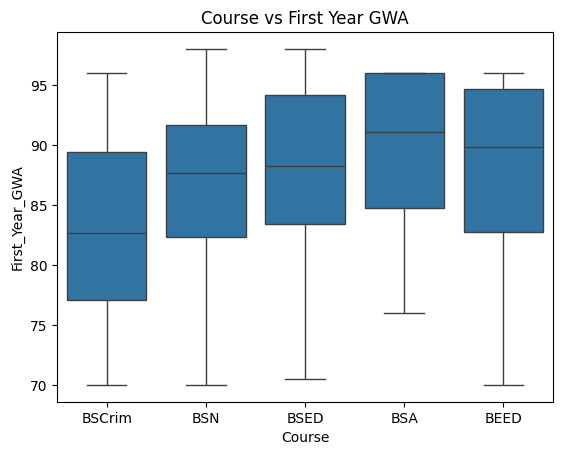

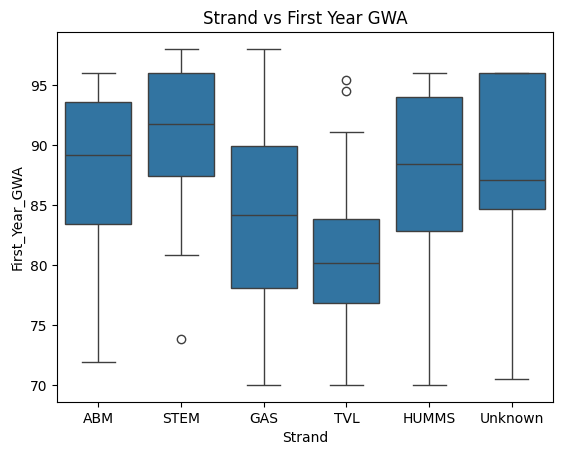

In [13]:
# Boxplots
sns.boxplot(x="Course", y="First_Year_GWA", data=df)
plt.title("Course vs First Year GWA")
plt.show()

sns.boxplot(x="Strand", y="First_Year_GWA", data=df)
plt.title("Strand vs First Year GWA")
plt.show()